## Time Series Analysis on Air passengers Dataset

## Project Objective
To analyze the Air Passengers time series dataset in order to identify trend and seasonal patterns and to build an appropriate forecasting model for predicting future airline passenger demand.

## Dataset Description
| Column Name | Description                                  |
| ----------- | -------------------------------------------- |
| month       | Represents the year and month of observation |
| passengers  | Number of airline passengers per month       |


## Importing packages

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
data = pd.read_csv(r'D:\ds ai ml\DS@AI\00-portfolio-projects\walmart Time Series Analysis\AirPassengers.csv')
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [4]:
data.shape

(144, 2)

## Data preprocessing

In [5]:
# column formatting
data=data.rename(columns= {'Month': 'month', '#Passengers':'passengers'})

In [6]:
# changing Data type of month

# data['month']=pd.to_datetime(data['month'], format='%Y-%m') #converting month column to date time
data['month']=pd.to_datetime(data['month'], dayfirst =True) #converting month column to date time
data

,month,passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [7]:
data.index=data['month']  # or data= data.set_index('month') #making month as index column
del data['month']
data

,passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [8]:
data.describe()  # Summary

,passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


## Exploratory Data Analysis

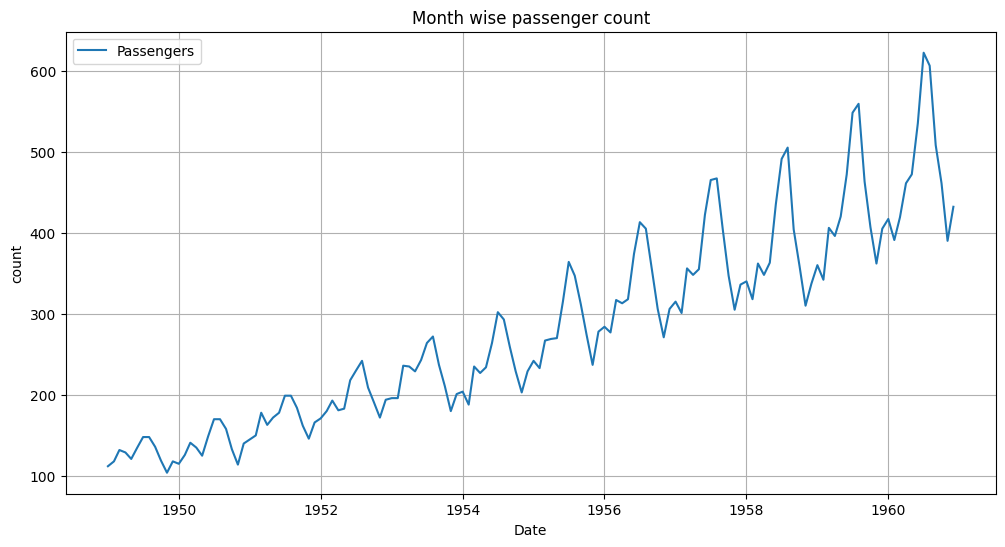

In [9]:
# Plotting passenger data
plt.figure(figsize=(12, 6))
plt.plot(data, label='Passengers')
plt.title('Month wise passenger count')
plt.xlabel('Date')
plt.ylabel('count')
plt.legend()
plt.grid(True)
plt.show()


###  Seasonal Decomposition

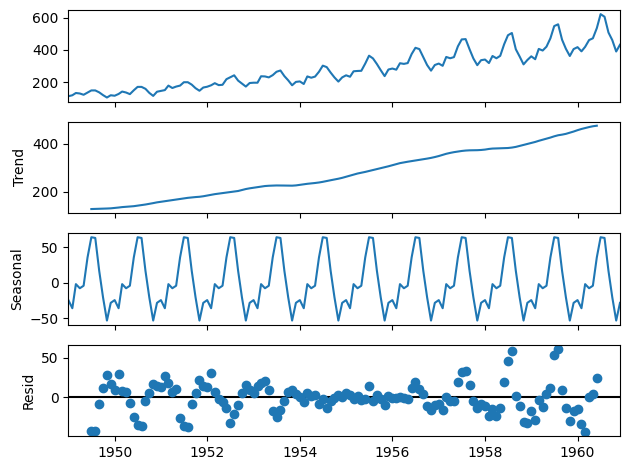

In [10]:
# Original Data
from statsmodels.tsa.seasonal import seasonal_decompose

decom=seasonal_decompose(data)
decom.plot();


### Function to test stationarity

In [11]:
def test_stationarity(dataFrame, var):
    dataFrame['RollMean']  = dataFrame[var].rolling(window=12).mean()
    dataFrame['RollStd']  = dataFrame[var].rolling(window=12).std()

    from statsmodels.tsa.stattools import adfuller
    adfTest = adfuller(dataFrame[var],autolag='AIC')
    stats = pd.Series(adfTest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
    print(stats.map('{:.7f}'.format))

    for key, values in adfTest[4].items():
        print('criticality',key,":",values)

    p_value=stats[1]
    if p_value <=0.05:
        print('stationarity is present')
    else:
        print('no stationarity')

    plt.figure(figsize=(15,6))
    sns.lineplot(data=dataFrame,x=dataFrame.index,y=var, color='blue', label=var)
    sns.lineplot(data=dataFrame,x=dataFrame.index,y='RollMean',color='orange', label='Rolling Mean')
    sns.lineplot(data=dataFrame,x=dataFrame.index,y='RollStd',color='green', label='Rolling Std')
    plt.legend()

#### Test stationarity for original data

Test Statistic                   0.8153689
p-value                          0.9918802
#lags used                      13.0000000
number of observations used    130.0000000
dtype: object
criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598
no stationarity


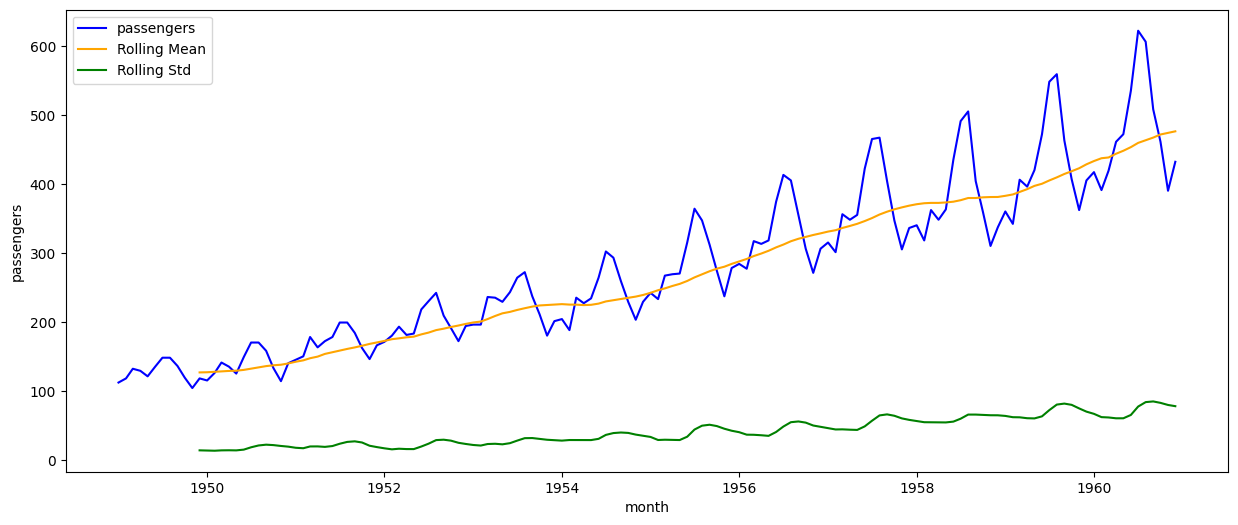

In [12]:
test_stationarity(data,'passengers')

### Function to Plot Autocorrelation and Partial Autocorrelation

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def acf_pacf(df,var, acf_lag=40, pacf_lag=40):
    series = df[var].dropna()

    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    plot_acf(series, ax=axes[0], lags=acf_lag)
    axes[0].set_title("ACF")

    plot_pacf(series, ax=axes[1], lags=pacf_lag, method="ywm")
    axes[1].set_title("PACF")

    plt.tight_layout()
    plt.show()



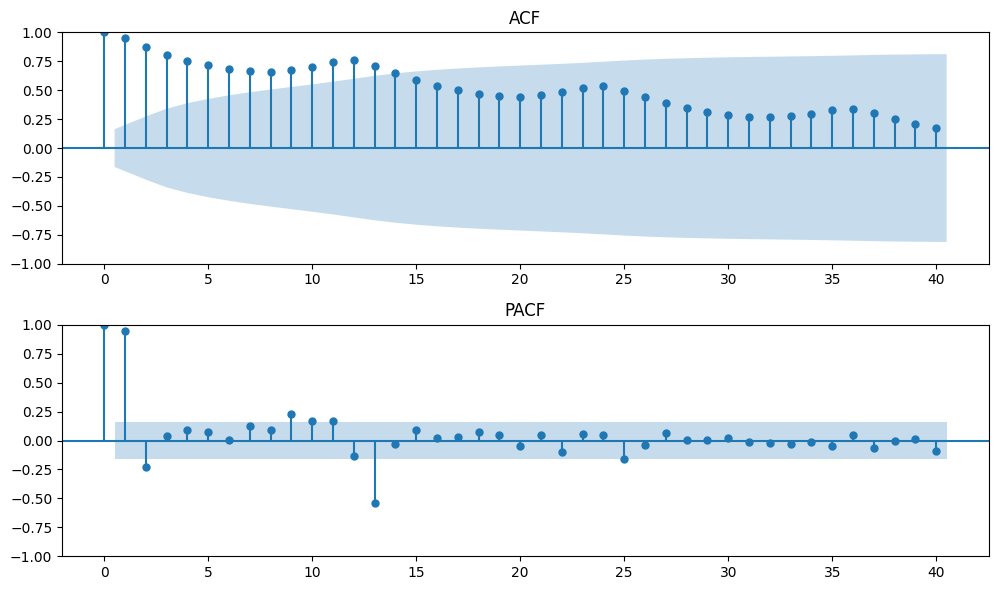

In [14]:
acf_pacf(data, 'passengers',40,40)

The time series plot and correlation plots show that the data has a trend and fluctuating variance. The fan-shaped pattern in the ACF indicates changing variance, suggesting that a log transformation is needed. Additionally, the slow decay of the ACF implies a non-stationary mean, indicating that differencing is required to make the series stationary.

### Log transformation

In [15]:
#logrithmic computation to make the time series stationary
log_data = np.log(data)
first_log = log_data.dropna()

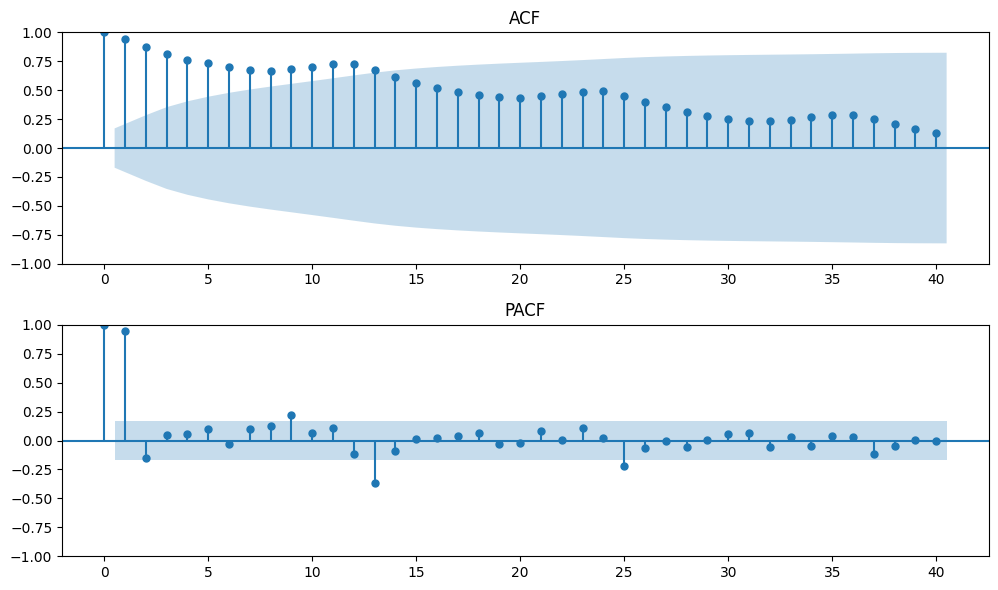

In [16]:
acf_pacf(first_log, 'passengers',40,40)

### Differencing

In [17]:
log_diff= first_log.diff().dropna()

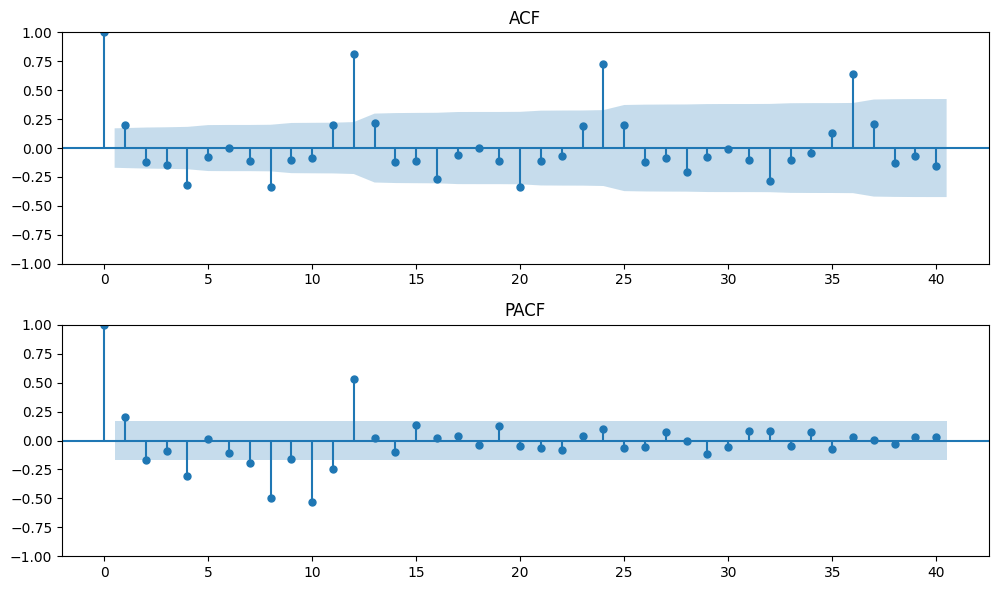

In [18]:
acf_pacf(log_diff, 'passengers',40,40)

Test Statistic                  -3.1122902
p-value                          0.0256569
#lags used                      13.0000000
number of observations used    118.0000000
dtype: object
criticality 1% : -3.4870216863700767
criticality 5% : -2.8863625166643136
criticality 10% : -2.580009026141913
stationarity is present


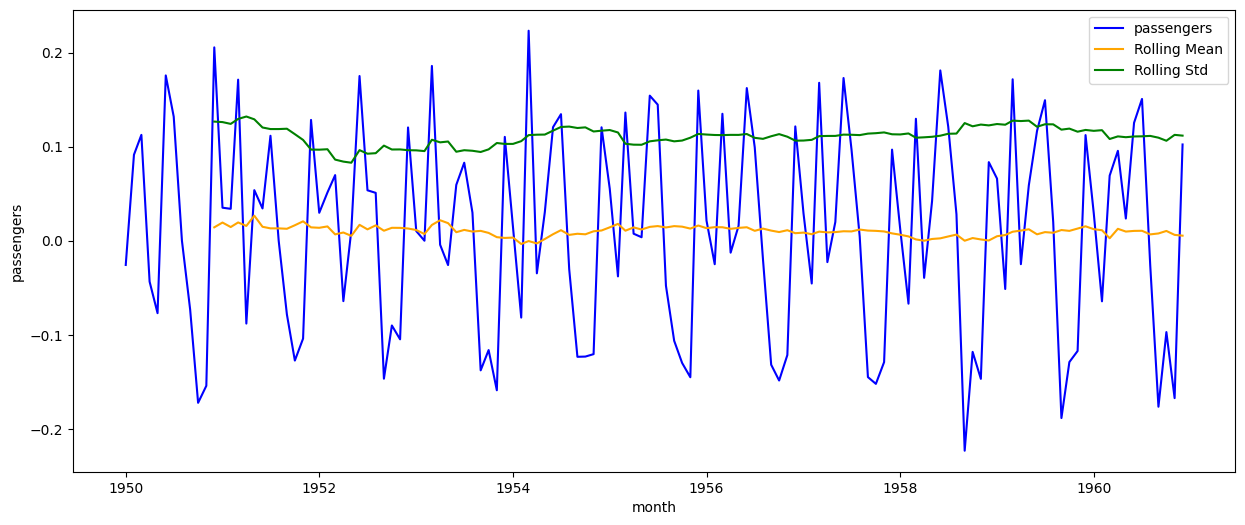

In [19]:
test_stationarity(log_diff,'passengers')

- After differencing the log-transformed data, stationarity is achieved. From the plots, we observe that one regular differencing is sufficient, suggesting a non-seasonal order of **(p,d,q) = (2,1,1)**.
- Seasonal spikes at lags 12, 24, 36… indicate annual seasonality, so a seasonal differencing is applied to the trend-differenced data to remove the seasonal effect.

### Seasonal Differencing

In [20]:
seasonal_diff = log_diff.diff(12)

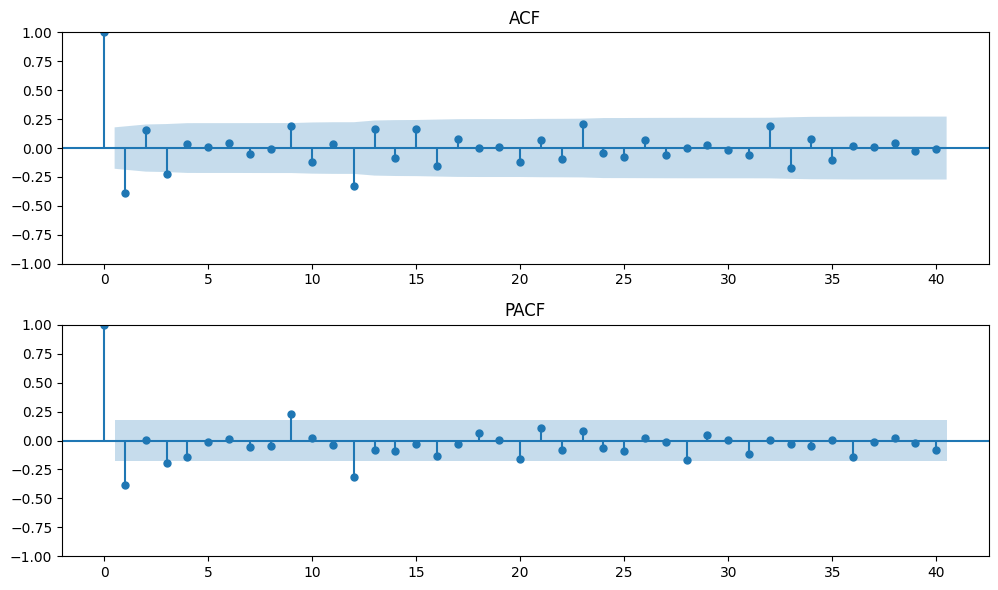

In [21]:
acf_pacf(seasonal_diff, 'passengers',40,40)

- The seasonal order is  **(p,d,q)(P,D,Q)12=(2,1,1)(1,1,1)12** 

- Seasonal differencing is applied to the trend-differenced data to remove the yearly seasonality indicated by spikes at lags 12, 24, 36, etc.

## Time Series Analysis on log transformed data

In [22]:
ts=first_log
ts

,passengers,RollMean,RollStd
month,,,
1949-12-01,4.770685,4.841559,2.618865
1950-01-01,4.744932,4.843531,2.599228
1950-02-01,4.836282,4.848770,2.577674
1950-03-01,4.948760,4.854631,2.616445
1950-04-01,4.905275,4.858520,2.626295
...,...,...,...
1960-08-01,6.406880,6.138447,4.426408
1960-09-01,6.230481,6.146508,4.438138
1960-10-01,6.133398,6.156096,4.413307


### Train test split

In [23]:
train= ts['passengers'].iloc[:120].dropna()
test= ts['passengers'].iloc[120:].dropna()


In [24]:
# !pip install pmdarima
from pmdarima import auto_arima

## ARIMA Model

In [25]:
# auto_arima for ARIMA (non-seasonal)
arima_model=auto_arima(train,seasonal=False,trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.03 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-189.988, Time=0.19 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-192.877, Time=0.29 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-194.615, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-191.071, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-201.826, Time=0.28 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.94 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.71 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.66 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-194.065, Time=0.26 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-203.120, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-196.060, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-194.312, Time=0.07 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-204.957, Time=0.22 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-195.233, T

#### ARIMA model for order(2,1,1) from correlation plot

In [26]:
from statsmodels.tsa.arima.model import ARIMA
model_ar_plot=ARIMA(train,order=(2,1,1)) 
model_ar_plot=model_ar_plot.fit()
model_ar_plot.summary() 

C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             passengers   No. Observations:                  120
Model:                 ARIMA(2, 1, 1)   Log Likelihood                 106.479
Date:                Thu, 15 Jan 2026   AIC                           -204.957
Time:                        22:28:03   BIC                           -193.841
Sample:                    12-01-1949   HQIC                          -200.443
                         - 11-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9849      0.116      8.475      0.000       0.757       1.213
ar.L2         -0.3685      0.133     -2.772      0.006      -0.629      -0.108
ma.L1         -0.8328      0.120     -6.919      0.000      -1.069      -0.597
sigma2         0.0097      0.002      5.606      0.000       0.006       0.013
===================================================================================
Ljung-Box (L1) (Q):                   1.00   Jarque-Bera (JB):                 7.66
Prob(Q):                              0.32   Prob(JB):                         0.02
Heteroskedasticity (H):               1.03   Skew:                             0.27
Prob(H) (two-sided):                  0.92   Kurtosis:                         1.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Forecast for ARIMA model for order(2,1,1) from correlation plot

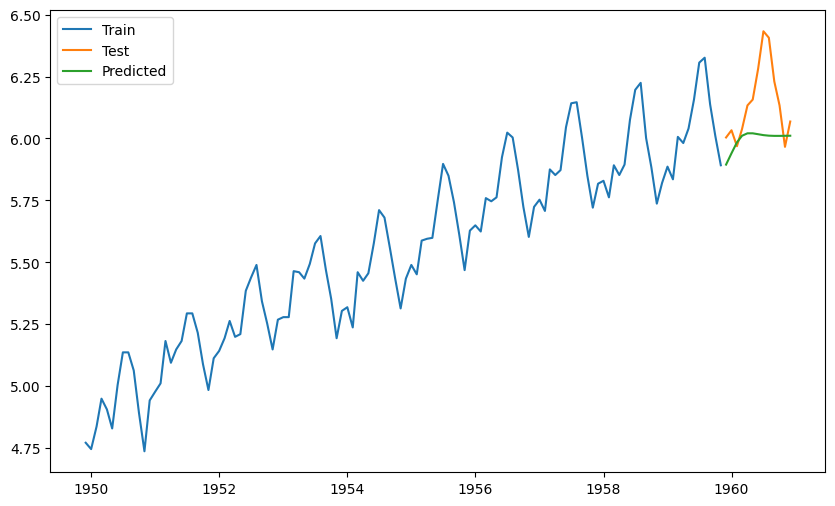

In [27]:
# Forecast for test set length
forecast = model_ar_plot.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    dynamic=False
)

# Align predictions with test set
# pred = forecast.values

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Predicted')
plt.legend()
plt.show()


#### Evaluation metrics

In [28]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE -(ARIMA - Corrrelation plot Order) :", rmse)



RMSE -(ARIMA - Corrrelation plot Order) : 0.20088615590577913


#### ARIMA model for order(4,1,3) from auto_arima

In [29]:
from statsmodels.tsa.arima.model import ARIMA
model_ar_auto=ARIMA(train,order=(4,1,3)) 
model_ar_auto=model_ar_auto.fit()
model_ar_auto.summary() 



C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             passengers   No. Observations:                  120
Model:                 ARIMA(4, 1, 3)   Log Likelihood                 125.606
Date:                Thu, 15 Jan 2026   AIC                           -235.211
Time:                        22:28:05   BIC                           -212.978
Sample:                    12-01-1949   HQIC                          -226.183
                         - 11-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8806      0.158      5.565      0.000       0.570       1.191
ar.L2          0.2394      0.227      1.056      0.291      -0.205       0.684
ar.L3         -0.4589      0.177     -2.593      0.010      -0.806      -0.112
ar.L4         -0.2014      0.131     -1.543      0.123      -0.457       0.054
ma.L1         -0.9018      0.112     -8.079      0.000      -1.121      -0.683
ma.L2         -0.6382      0.135     -4.717      0.000      -0.903      -0.373
ma.L3          0.8668      0.116      7.462      0.000       0.639       1.095
sigma2         0.0065      0.001      5.923      0.000       0.004       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.67   Jarque-Bera (JB):                 5.12
Prob(Q):                              0.41   Prob(JB):                         0.08
Heteroskedasticity (H):               0.82   Skew:                             0.42
Prob(H) (two-sided):                  0.54   Kurtosis:                         2.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Forecast for ARIMA model for order (4,1,3) from auto_arima 

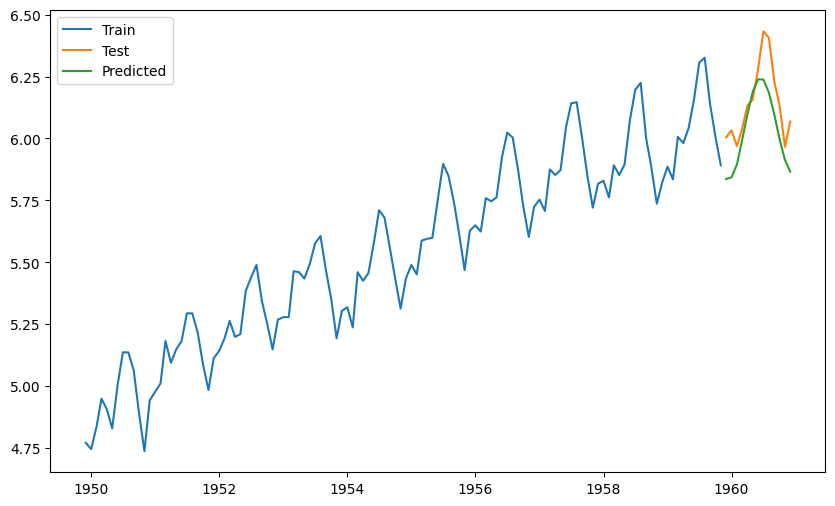

In [30]:
# Forecast for test set length
forecast = model_ar_auto.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    dynamic=False
)

# Align predictions with test set
# pred = forecast.values

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Predicted')
plt.legend()
plt.show()


In [31]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE - (ARIMA - auto_arima order):", rmse)



RMSE - (ARIMA - auto_arima order): 0.13684858484925


### Observation of ARIMA model:
The ARIMA model with order (2,1,1) from correlation plots and (4,1,3) from auto_arima both deviate from the test data, with RMSE values of 0.2009 and 0.1368, respectively. The auto_arima model performs better, showing a closer fit to the observed data.

## SARIMA Model

In [32]:
# auto_arima for ARIMA (seasonal)
sarima_model=auto_arima(train,seasonal=True,trace=True, m=12, stepwise = True, max_p=5,max_P=5,max_q=5,max_Q=5,max_d = 2,max_D=1) 
sarima_model.order


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-391.835, Time=3.23 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-189.988, Time=0.11 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=1.41 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-269.827, Time=0.75 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-191.071, Time=0.10 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=-279.835, Time=1.93 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=-387.295, Time=1.86 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=-388.757, Time=4.88 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=-397.921, Time=6.24 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=5.33 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=-395.652, Time=4.59 sec
 ARIMA(2,1,2)(1,0,3)[12] intercept   : AIC=-386.993, Time=17.45 sec
 ARIMA(2,1,2)(0,0,3)[12] intercept   : AIC=inf, Time=14.91 sec
 ARIMA(2,1,2)(2,0,3)[12] intercept   : AIC=-394.964, Time=23.79 sec
 ARIMA(1,1,2)(1,0,2)[12] interc

(0, 1, 1)

#### SARIMA model for order (2,1,1)(1,1,1,12)) from correlation plot

In [33]:
#plot order
from statsmodels.tsa.statespace.sarimax import SARIMAX,SARIMAXResults

model_sarima_plot = SARIMAX(train,order=(2,1,1),seasonal_order=(1,1,1,12))    
model_sarima_plot=model_sarima_plot.fit()
model_sarima_plot.summary()

C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         passengers   No. Observations:                  120
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 197.823
Date:                            Thu, 15 Jan 2026   AIC                           -383.646
Time:                                    22:31:14   BIC                           -367.609
Sample:                                12-01-1949   HQIC                          -377.145
                                     - 11-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0993      1.542     -0.064      0.949      -3.121       2.923
ar.L2          0.0359      0.580      0.062      0.951      -1.101       1.173
ma.L1         -0.2746      1.521     -0.181      0.857      -3.255       2.706
ar.S.L12      -0.0343      0.237     -0.145      0.885      -0.500       0.431
ma.S.L12      -0.5117      0.251     -2.040      0.041      -1.003      -0.020
sigma2         0.0014      0.000      7.670      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.53
Prob(Q):                              0.97   Prob(JB):                         0.77
Heteroskedasticity (H):               0.33   Skew:                            -0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Forecast for SARIMA model for order (2,1,1)(1,1,1,12)) from correlation plot

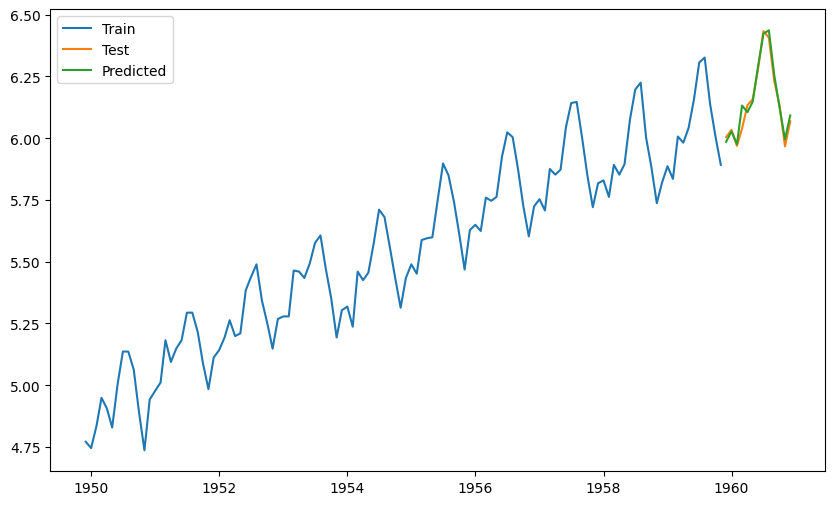

In [34]:
# Forecast for test set length
forecast = model_sarima_plot.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    dynamic=False
)

# Align predictions with test set
# pred = forecast.values

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Predicted')
plt.legend()
plt.show()


In [35]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE -(SARIMA - Corrrelation plot Order):", rmse)



RMSE -(SARIMA - Corrrelation plot Order): 0.032045313778093366


#### SARIMA model for order (0,1,1)(1,0,1)[12] from auto_arima

In [36]:
# auto arima Best model:  ARIMA(0,1,1)(1,0,1)[12]  
model_sarima_auto = SARIMAX(train,order=(0,1,1),seasonal_order=(1,0,1,12))    
model_sarima_auto=model_sarima_auto.fit()
model_sarima_auto.summary()

C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         passengers   No. Observations:                  120
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 206.426
Date:                            Thu, 15 Jan 2026   AIC                           -404.851
Time:                                    22:31:16   BIC                           -393.735
Sample:                                12-01-1949   HQIC                          -400.337
                                     - 11-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3277      0.082     -3.980      0.000      -0.489      -0.166
ar.S.L12       0.9897      0.007    137.814      0.000       0.976       1.004
ma.S.L12      -0.5460      0.107     -5.082      0.000      -0.757      -0.335
sigma2         0.0014      0.000      7.875      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.14
Prob(Q):                              0.95   Prob(JB):                         0.93
Heteroskedasticity (H):               0.36   Skew:                            -0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Forecast for SARIMA model for order (0,1,1)(1,0,1)[12] from auto_arima

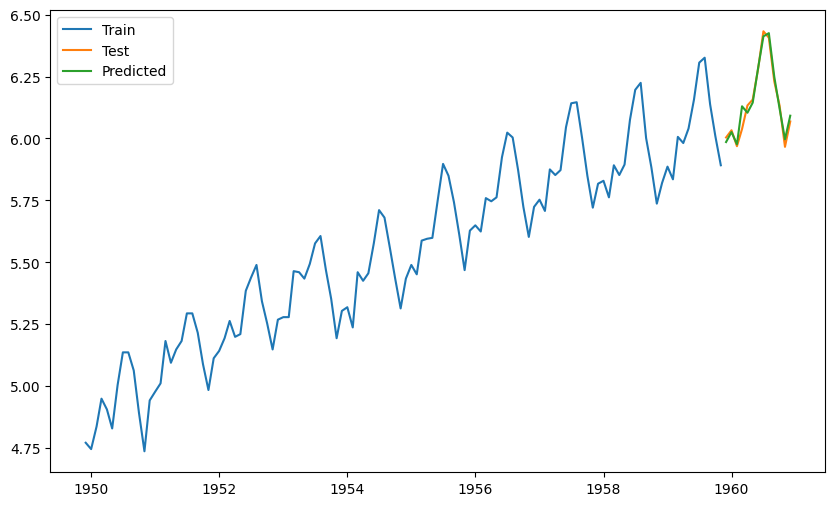

In [37]:
# Forecast for test set length
forecast = model_sarima_auto.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    dynamic=False
)

# Align predictions with test set
# pred = forecast.values

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Predicted')
plt.legend()
plt.show()


In [38]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test, forecast))
print('RMSE - (SARIMA - auto_arima order):', rmse)



RMSE - (SARIMA - auto_arima order): 0.031223194740493388


#### Observation:

- The SARIMA model demonstrates excellent performance, with values closely matching the observed data.
- **Among the models tested, SARIMA (0,1,1)(1,0,1)[12], selected using auto_arima, provides the best fit and is chosen as the final model for the time series analysis**.



## Final SARIMA model with order (0,1,1)(1,0,1)[12] on log transformed data

In [39]:
model_sarima = SARIMAX(ts['passengers'],order=(0,1,1),seasonal_order=(1,0,1,12))    
model_sarima=model_sarima.fit()
model_sarima.summary()

C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ACER\anaconda3\envs\ml_dl_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         passengers   No. Observations:                  133
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 229.825
Date:                            Thu, 15 Jan 2026   AIC                           -451.651
Time:                                    22:31:18   BIC                           -440.120
Sample:                                12-01-1949   HQIC                          -446.965
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3805      0.074     -5.153      0.000      -0.525      -0.236
ar.S.L12       0.9897      0.007    142.698      0.000       0.976       1.003
ma.S.L12      -0.5423      0.107     -5.069      0.000      -0.752      -0.333
sigma2         0.0014      0.000      8.585      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.44
Prob(Q):                              0.86   Prob(JB):                         0.80
Heteroskedasticity (H):               0.55   Skew:                            -0.00
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Forecast future data

In [40]:
n_periods = 24

forecast_result = model_sarima.forecast(steps=n_periods)
forecast_result = np.exp(forecast_result)  # reverse log transform

future_index = pd.date_range(start=data.index[-1] + pd.offsets.MonthBegin(1), 
                             periods=n_periods, freq='MS')

forecast_series = pd.Series(forecast_result, index=future_index)

#### Plot forecast data

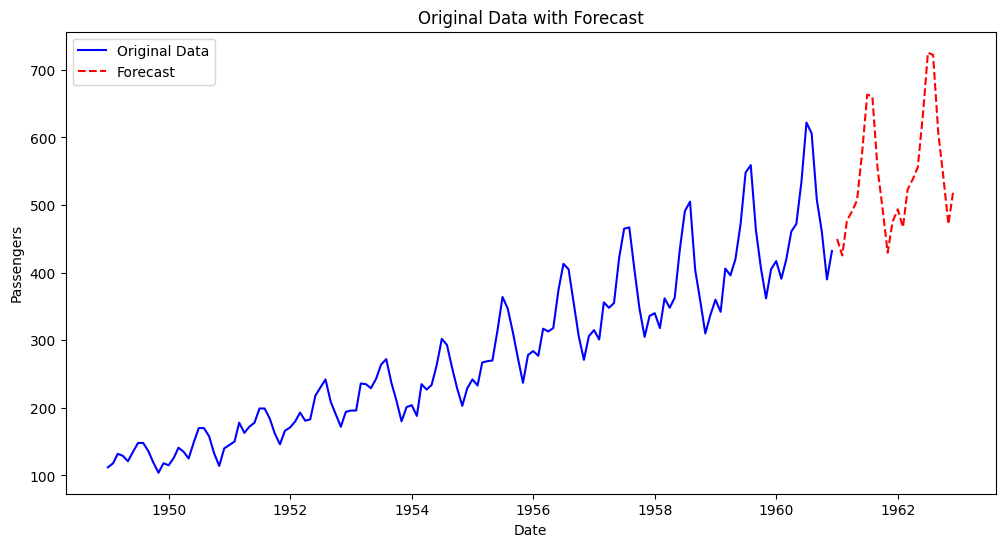

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data['passengers'], label='Original Data', color='blue')
plt.plot(forecast_series.index, forecast_series, label='Forecast', color='red', linestyle='--')
plt.title('Original Data with Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()


## Conclusion
- The air passengers dataset shows clear trends and seasonal patterns. Log transformation and differencing were applied to achieve stationarity.

- ARIMA Models:

    Order (2,1,1) from correlation plots: RMSE = 0.2009

    Order (4,1,3) from auto_arima: RMSE = 0.1368

    Auto ARIMA performed better but still deviates from the observed data.

- SARIMA Models:

    Correlation plot order (2,1,1)(1,1,1,12): RMSE = 0.0320

    Auto ARIMA order (0,1,1)(1,0,1)[12]: RMSE = 0.0312 → best fit

- Final Model:
SARIMA (0,1,1)(1,0,1)[12] on log-transformed data, used for forecasting the next 24 months, providing reliable predictions.

- Key Insight:
Accounting for seasonality significantly improves forecasting accuracy.